# Read in FY2025

Import your packages

In [1]:
using Base.Threads
println(nthreads())

4


In [2]:
import Pkg
# This installs only the modern, compatible versions
Pkg.add(["DataFrames", "CSV", "InlineStrings", "Plots",
"Colors","StatsPlots", "Statistics", "XLSX", "Dates", "StatsBase", 
"CategoricalArrays", "Missings", "Chain", "FreqTables", "Glob", "MLJ",
"DecisionTree", "XGBoost", "LoggingExtras", "IJulia", "Parquet2"])


   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [3]:
using DataFrames, CSV, Statistics, Dates, Logging, Parquet2, Glob
using Plots, StatsPlots, DataFrames, StatsBase, Dates, Printf, Colors
using DecisionTree, XGBoost
using Base.Threads
using Printf, StatsBase, Plots, StatsPlots, Statistics
using DecisionTree, XGBoost, Logging

Functions

Read in your file

In [4]:
filename = "../data/2_ready_for_EDA/raw_fy2017_2025/combined_spending_2017_2025.parquet"
# Load the parquet file
ds = Parquet2.Dataset(filename)
# Convert it to a DataFrame
df = DataFrame(ds)



Row,parent_award_agency_id,award_amount,action_date,period_of_performance_start_date,awarding_sub_agency_name,recipient_uei,primary_place_of_performance_zip_5,type_of_contract_pricing,contract_description,product_or_service_code,naics_code,extent_competed,fiscal_year
,String?,Float64?,DateTime?,DateTime?,String?,String?,String?,String?,String?,String?,String?,String?,Int64?
1,missing,0.0,2017-03-16T00:00:00,2017-03-17T00:00:00,Department of the Air Force,EZZLZJRCKRC3,92128,COST PLUS AWARD FEE,"GLOBAL HAWK, ACAT ID, MXGUI CDRL UPDATE",1510,336411,NOT COMPETED,2017
2,missing,656106.0,2017-07-28T00:00:00,2017-07-28T00:00:00,Department of the Air Force,LHJPD6T16EV9,80916,COST PLUS INCENTIVE FEE,GROUND BASED ELECTRO OPTICAL DEEP SPACE SURVEILLANCE RAPID DEPLOYMENT PROCESS 5.0 PROJECT,J058,334511,FULL AND OPEN COMPETITION,2017
3,missing,2.61431e5,2017-08-31T00:00:00,2017-08-31T00:00:00,Department of the Air Force,CHM5ZAJTSS99,31088,FIRM FIXED PRICE,RADAR WARNING RECEIVER,5895,334511,NOT AVAILABLE FOR COMPETITION,2017
4,missing,301064.0,2016-10-14T00:00:00,2016-10-14T00:00:00,Department of the Air Force,LX3BSV6NNW58,99704,FIRM FIXED PRICE,"OPERATIONS, MAINTENANCE, AND SUPPORT OF THE SOLID STATE PHASED ARRAY SYSTEM (SSPARS).",M123,517910,FULL AND OPEN COMPETITION,2017
5,missing,1.12128e7,2016-12-27T00:00:00,2018-03-31T00:00:00,Department of the Air Force,LFMMBZEMM2X3,32548,COST NO FEE,IGF::CT::IGF EGLIN OPERATION&MAINTENANCE SERVICES INCREMENTAL FUNDING,H210,541330,FULL AND OPEN COMPETITION,2017
6,missing,19200.0,2017-09-19T00:00:00,2017-09-19T00:00:00,Department of the Air Force,HHLEM3ZJKLS6,27526,FIRM FIXED PRICE,IGF::OT::IGF FLAG FOOTBALL OFFICIATING,G003,813990,COMPETED UNDER SAP,2017
7,missing,0.0,2017-07-21T00:00:00,2017-09-01T00:00:00,Department of the Air Force,LX3BSV6NNW58,99704,FIRM FIXED PRICE,"OPERATIONS, MAINTENANCE, AND SUPPORT OF THE SOLID STATE PHASED ARRAY SYSTEM (SSPARS).",M123,517910,FULL AND OPEN COMPETITION,2017
8,missing,4.25439e6,2016-10-24T00:00:00,2016-10-24T00:00:00,Department of the Air Force,LLK6MNEEK7A8,32542,FIRM FIXED PRICE,IGF::OT::IGF WATER STORAGE TANK SUSTAINMENT,J099,237110,FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES,2017
9,missing,-5360.0,2017-09-03T00:00:00,2017-09-03T00:00:00,Department of the Air Force,P8LRGPRLHLQ5,32542,FIRM FIXED PRICE,"YTZP(H), DISC, 55-10 2.15"" OD X 0.40"" TK",6635,327110,COMPETED UNDER SAP,2017


Create data dictionary for coded columns

In [5]:
stats_df = describe(df, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)
#CSV.write("stats-rawFY2017-2025.csv", stats_df, transform=(col, val) -> something(val, missing)) 

Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,Union,Int64,Union…,Any,Any,Any,Union…,Union…
1,parent_award_agency_id,"Union{Missing, String}",375210,25,0300,9700,,,
2,award_amount,"Union{Missing, Float64}",0,,-3.09971e8,3.87983e9,16350.0,7.39438e5,1.276e7
3,action_date,"Union{Missing, DateTime}",0,3250,2016-10-01T00:00:00,2025-09-30T00:00:00,2021-04-14T00:00:00,,
4,period_of_performance_start_date,"Union{Missing, DateTime}",7,5312,1987-06-15T00:00:00,2109-06-04T00:00:00,2019-10-04T00:00:00,,
5,awarding_sub_agency_name,"Union{Missing, String}",0,1,Department of the Air Force,Department of the Air Force,,,
6,recipient_uei,"Union{Missing, String}",1,34496,C113QWMDV467,ZZYLVTN9ZCQ8,,,
7,primary_place_of_performance_zip_5,"Union{Missing, String}",88871,7724,-,TUR,,,
8,type_of_contract_pricing,"Union{Missing, String}",0,15,COST NO FEE,TIME AND MATERIALS,,,
9,contract_description,"Union{Missing, String}",247,508121,!,`B180 SMALL PARTS PAINT BOOTH AND CURE OVEN,,,


In [6]:
shape = size(df)
println("The dataset has $(shape[1]) rows and $(shape[2]) columns.")

The dataset has 973394 rows and 13 columns.


# DATA PREPARATION

## Select desireable columns 
keep:
parent_award_agency_id
action_date
award_amount
period_of_performance_start_date
awarding_sub_agency_name
recipient_uei
primary_place_of_performance_zip_5
type_of_contract_pricing
contract_description
product_or_service_code
naics_code
extent_competed
fiscal_year



In [7]:
# Count where the column :my_column is exactly 0
zero_count = count(==(0), df.award_amount)

308079

In [8]:
# Check zero and negative award amounts
zeros_count = filter(row -> row.award_amount == 0, df)

println("=== Zero Award Rows by type_of_contract_pricing ===")
println(combine(groupby(zeros_count, :type_of_contract_pricing), nrow => :count) |> 
    x -> sort(x, :count, rev=true))

println("\n=== Zero Award Rows by extent_competed ===")
println(combine(groupby(zeros_count, :extent_competed), nrow => :count) |> 
    x -> sort(x, :count, rev=true))

println("\n=== Top 20 PSC codes in zero-award rows ===")
println(first(sort(combine(groupby(zeros_count, :product_or_service_code), nrow => :count), 
    :count, rev=true), 20))

# Distribution summary
println("\n=== award_amount distribution ===")
println(describe(df[!, [:award_amount]]))

println("\nNegative rows: $(sum(df.award_amount .< 0))")

# Clean: remove zero and negative
df_clean = filter(row -> row.award_amount > 0, df)

println("\nRemoved $(nrow(df) - nrow(df_clean)) rows ($(round((1 - nrow(df_clean)/nrow(df))*100, digits=1))%)")
println("Remaining rows: $(nrow(df_clean))")

=== Zero Award Rows by type_of_contract_pricing ===
15×2 DataFrame
 Row │ type_of_contract_pricing           count  
     │ Union{Missing, String}             Int64  
─────┼───────────────────────────────────────────
   1 │ FIRM FIXED PRICE                   211624
   2 │ COST PLUS FIXED FEE                 50994
   3 │ ORDER DEPENDENT (IDV ALLOWS PRIC…   24156
   4 │ COST NO FEE                          8029
   5 │ COST PLUS INCENTIVE FEE              3845
   6 │ FIXED PRICE INCENTIVE                3795
   7 │ TIME AND MATERIALS                   1667
   8 │ COST PLUS AWARD FEE                  1259
   9 │ FIXED PRICE LEVEL OF EFFORT           943
  10 │ LABOR HOURS                           663
  11 │ FIXED PRICE WITH ECONOMIC PRICE …     633
  12 │ FIXED PRICE AWARD FEE                 206
  13 │ COST SHARING                          181
  14 │ FIXED PRICE REDETERMINATION            45
  15 │ OTHER (APPLIES TO AWARDS WHERE N…      39

=== Zero Award Rows by extent_competed ===
7×2 

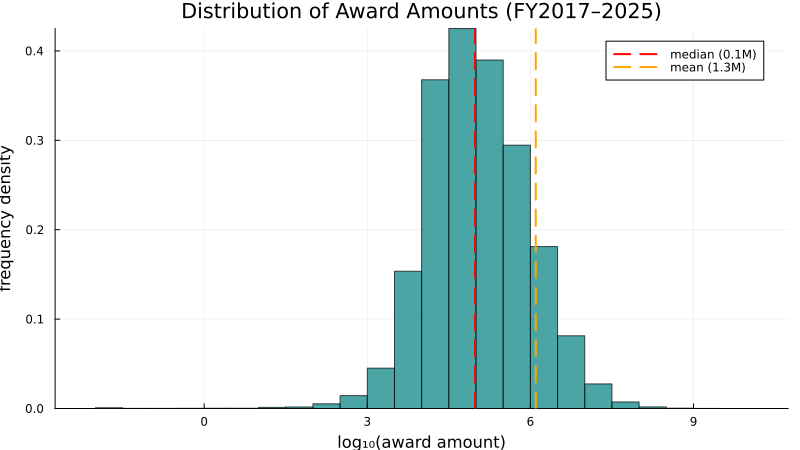

In [9]:
non_zero = filter(row -> row.award_amount > 0, df_clean).award_amount
log_amounts = log10.(non_zero)

histogram(log_amounts,
    normalize = :pdf,
    bins = 50,
    xlabel = "log₁₀(award amount)",
    ylabel = "frequency density",
    title = "Distribution of Award Amounts (FY2017–2025)",
    label = false,
    color = :teal,
    alpha = 0.7,
    size = (800, 450)
)

# Add median and mean lines
vline!([log10(median(non_zero))], label = "median ($(round(median(non_zero)/1e6, digits=1))M)", color = :red, linestyle = :dash, linewidth = 2)
vline!([log10(mean(non_zero))], label = "mean ($(round(mean(non_zero)/1e6, digits=1))M)", color = :orange, linestyle = :dash, linewidth = 2)

In [10]:
stats_df = describe(df_clean, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)
vscodedisplay(stats_df)
#CSV.write("stats-FY2017-2025.csv", stats_df, transform=(col, val) -> something(val, missing), ) 

## Fix missing values
1. Drop the 19 naics_code rows
2. Create missing as additional parent award agency column
3. Sentinel-fill primary_place_of_performance_zip_5
4. Fill missing contract_description with missing
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df_clean</b> after this step.
</div>

In [ ]:
# 1. Drop the 19 naics_code missing rows
df_clean = dropmissing(df_clean, [:naics_code, :period_of_performance_start_date])
#df_clean = dropmissing(df_clean, :naics_code)

# 2. parent_award_agency_id — fill missing with sentinel, add binary flag
df_clean.parent_award_agency_id = coalesce.(df_clean.parent_award_agency_id, "MISSING_AGENCY_ID")

# 3. primary_place_of_performance_zip_5 — fill with sentinel
df_clean.primary_place_of_performance_zip_5 = coalesce.(df_clean.primary_place_of_performance_zip_5, "00000")

# 4. contract_description — fill with empty string
df_clean.contract_description = coalesce.(df_clean.contract_description, "")

# 5. Remove awarding_sub_agency_name (too many missings)
select!(df_clean, Not(:awarding_sub_agency_name))

# Verify no remaining missings
println(describe(df_clean, :nmissing))

12×2 DataFrame
 Row │ variable                           nmissing 
     │ Symbol                             Int64    
─────┼─────────────────────────────────────────────
   1 │ parent_award_agency_id                    0
   2 │ award_amount                              0
   3 │ action_date                               0
   4 │ period_of_performance_start_date          0
   5 │ recipient_uei                             0
   6 │ primary_place_of_performance_zip…         0
   7 │ type_of_contract_pricing                  0
   8 │ contract_description                      0
   9 │ product_or_service_code                   0
  10 │ naics_code                                0
  11 │ extent_competed                           0
  12 │ fiscal_year                               0


In [12]:
stats_df = describe(df_clean, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)


Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,Type,Int64,Union…,Any,Any,Any,Union…,Union…
1,parent_award_agency_id,String,0,23,0300,MISSING_AGENCY_ID,,,
2,award_amount,"Union{Missing, Float64}",0,,0.01,3.87983e9,95780.0,1.25501e6,1.62915e7
3,action_date,"Union{Missing, DateTime}",0,3182,2016-10-01T00:00:00,2025-09-30T00:00:00,2021-03-01T00:00:00,,
4,period_of_performance_start_date,DateTime,0,4291,1995-11-08T00:00:00,2109-06-04T00:00:00,2020-02-20T00:00:00,,
5,recipient_uei,"Union{Missing, String}",0,31985,C113QWMDV467,ZZYLVTN9ZCQ8,,,
6,primary_place_of_performance_zip_5,String,0,7544,-,QAT,,,
7,type_of_contract_pricing,"Union{Missing, String}",0,13,COST NO FEE,TIME AND MATERIALS,,,
8,contract_description,String,0,352606,,_,,,
9,product_or_service_code,"Union{Missing, String}",0,1920,1005,Z300,,,


## Fix numerical columns

### Add duration columns and remove date columns

In [13]:
df1 = copy(df_clean)

# Create action_to_start_days
df1.action_to_start_days = Dates.value.(
    Dates.Day.(df1.period_of_performance_start_date .- df1.action_date)
)

# Extract start year
df1.performance_start_year = Dates.year.(df1.period_of_performance_start_date)

# Drop period_of_performance_start_date, action_date, and fiscal_year
select!(df1, Not([:period_of_performance_start_date, :action_date, :fiscal_year]))

# Force types

# Numeric columns
df1.award_amount = Float64.(df1.award_amount)
# String columns
df1.recipient_uei = String.(df1.recipient_uei)
df1.type_of_contract_pricing = String.(df1.type_of_contract_pricing)
df1.product_or_service_code = String.(df1.product_or_service_code)
df1.extent_competed = String.(df1.extent_competed)


593165-element Vector{String}:
 "FULL AND OPEN COMPETITION"
 "NOT AVAILABLE FOR COMPETITION"
 "FULL AND OPEN COMPETITION"
 "FULL AND OPEN COMPETITION"
 "COMPETED UNDER SAP"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "NOT COMPETED"
 "FULL AND OPEN COMPETITION"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "COMPETED UNDER SAP"
 ⋮
 "NOT COMPETED"
 "NOT AVAILABLE FOR COMPETITION"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "COMPETED UNDER SAP"
 "NOT COMPETED"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"
 "FULL AND OPEN COMPETITION"
 "FULL AND OPEN COMPETITION AFTER EXCLUSION OF SOURCES"

In [14]:
stats_df = describe(df1, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)


Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,parent_award_agency_id,String,0,23,0300,MISSING_AGENCY_ID,,,
2,award_amount,Float64,0,,0.01,3.87983e9,95780.0,1.25501e6,1.62915e7
3,recipient_uei,String,0,31985,C113QWMDV467,ZZYLVTN9ZCQ8,,,
4,primary_place_of_performance_zip_5,String,0,7544,-,QAT,,,
5,type_of_contract_pricing,String,0,13,COST NO FEE,TIME AND MATERIALS,,,
6,contract_description,String,0,352606,,_,,,
7,product_or_service_code,String,0,1920,1005,Z300,,,
8,naics_code,String,0,888,111110,928110,,,
9,extent_competed,String,0,6,COMPETED UNDER SAP,NOT COMPETED UNDER SAP,,,


### Remove outliers in performance start year

<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df2</b> after this step.
</div>

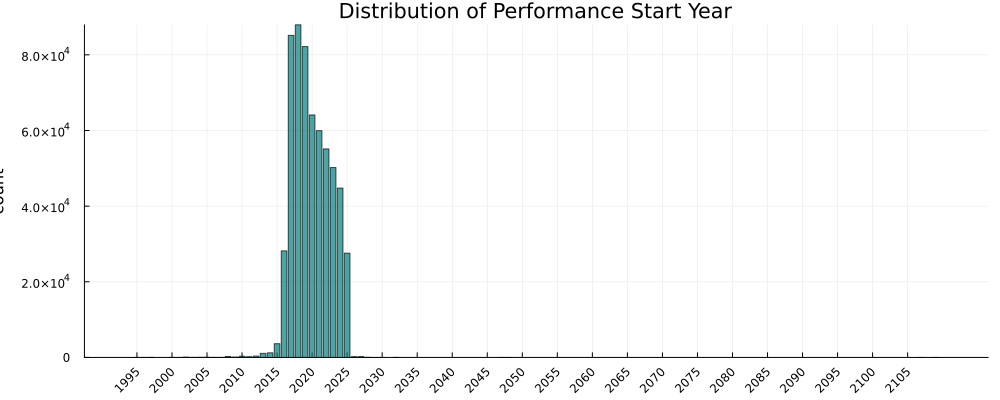

In [15]:
year_counts = combine(groupby(df1, :performance_start_year), nrow => :count)
sort!(year_counts, :performance_start_year)

bar(year_counts.performance_start_year, year_counts.count,
    xlabel = "performance start year",
    ylabel = "count",
    title = "Distribution of Performance Start Year",
    label = false,
    color = :teal,
    alpha = 0.7,
    size = (1000, 400),
    xticks = (minimum(year_counts.performance_start_year):5:maximum(year_counts.performance_start_year), 
              string.(minimum(year_counts.performance_start_year):5:maximum(year_counts.performance_start_year))),
    xrotation = 45
)

In [16]:
println("Before 2015: $(sum(df1.performance_start_year .< 2015))")
println("After 2030: $(sum(df1.performance_start_year .> 2030))")

# See all outlier years and their counts
outliers = filter(row -> row.performance_start_year < 2015 || row.performance_start_year > 2030, df1)
println(sort(combine(groupby(outliers, :performance_start_year), nrow => :count), :performance_start_year))

Before 2015: 3871
After 2030: 25
23×2 DataFrame
 Row │ performance_start_year  count 
     │ Int64                   Int64 
─────┼───────────────────────────────
   1 │                   1995      2
   2 │                   1996      3
   3 │                   1997     18
   4 │                   2000     30
   5 │                   2001     14
   6 │                   2002     90
   7 │                   2003     28
   8 │                   2004     45
   9 │                   2005     51
  10 │                   2006     17
  11 │                   2007     28
  12 │                   2008    251
  13 │                   2009    116
  14 │                   2010    331
  15 │                   2011    194
  16 │                   2012    356
  17 │                   2013   1076
  18 │                   2014   1221
  19 │                   2032     21
  20 │                   2047      1
  21 │                   2048      1
  22 │                   2107      1
  23 │                  

In [17]:
df2 = copy(df1)
df2 = filter(row -> row.performance_start_year <= 2048, df2)
# See all outlier years and their counts
outliers = filter(row -> row.performance_start_year < 2015 || row.performance_start_year > 2030, df2)
println(sort(combine(groupby(outliers, :performance_start_year), nrow => :count), :performance_start_year))

21×2 DataFrame
 Row │ performance_start_year  count 
     │ Int64                   Int64 
─────┼───────────────────────────────
   1 │                   1995      2
   2 │                   1996      3
   3 │                   1997     18
   4 │                   2000     30
   5 │                   2001     14
   6 │                   2002     90
   7 │                   2003     28
   8 │                   2004     45
   9 │                   2005     51
  10 │                   2006     17
  11 │                   2007     28
  12 │                   2008    251
  13 │                   2009    116
  14 │                   2010    331
  15 │                   2011    194
  16 │                   2012    356
  17 │                   2013   1076
  18 │                   2014   1221
  19 │                   2032     21
  20 │                   2047      1
  21 │                   2048      1


### Log transform award amount
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df3</b> after this step.
</div>

In [18]:
df3 = copy(df2)
df3.log_award_amount = log10.(df3.award_amount)
select!(df3, Not(:award_amount))
stats_df = describe(df3, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)

Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,parent_award_agency_id,String,0,23,0300,MISSING_AGENCY_ID,,,
2,recipient_uei,String,0,31985,C113QWMDV467,ZZYLVTN9ZCQ8,,,
3,primary_place_of_performance_zip_5,String,0,7544,-,QAT,,,
4,type_of_contract_pricing,String,0,13,COST NO FEE,TIME AND MATERIALS,,,
5,contract_description,String,0,352605,,_,,,
6,product_or_service_code,String,0,1920,1005,Z300,,,
7,naics_code,String,0,888,111110,928110,,,
8,extent_competed,String,0,6,COMPETED UNDER SAP,NOT COMPETED UNDER SAP,,,
9,action_to_start_days,Int64,0,,-10040,10958,0.0,-250.099,563.254


## Fix categorical columns
ok so now we need to fix the following columns:

DONE:

1. recipient UEI --> for now, nothing, but target encode after splitting into train and test but before you run model
2. contract description --> DROP for now
3. primary place of performance --> change to state code
4. product or service code --> roll up into cateogires
5. naics code --> roll up into 2 letter sector
6. type_of_contract_pricing --> for now nothing, but categorical encode when you run model

### Roll Up NAICS Code
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df4</b> after this step.
</div>

In [19]:
# 1. Group and Count
value_counts = combine(groupby(df3, :naics_code), nrow => :count)

# 2. Sort by count (descending to see the "biggest" offices first)
sort!(value_counts, :count, rev=true);


# Assuming your column is :naics_code and it might be stored as an Integer or String.
# We convert to string first to ensure we can use 'first' reliably.
naics_str = string.(df3.naics_code)

summary = DataFrame(
    Digits = [2, 3, 4, 5],
    Unique_Count = [
        length(unique(first.(naics_str, 2))),
        length(unique(first.(naics_str, 3))),
        length(unique(first.(naics_str, 4))),
        length(unique(first.(naics_str, 5)))
    ]
)

println(summary)

# Use the '!' symbol to update the column directly in your dataframe
df4 = copy(df3)

df4[!, :naics_code] = passmissing(first).(df4[!, :naics_code], 2) # choosing 2 digits for sector-level analysis
value_counts = combine(groupby(df4, :naics_code), nrow => :count)
sort!(value_counts, :count, rev=true)
rename!(df4, :naics_code => :naics_code_sector);

4×2 DataFrame
 Row │ Digits  Unique_Count 
     │ Int64   Int64        
─────┼──────────────────────
   1 │      2            24
   2 │      3            99
   3 │      4           286
   4 │      5           585


Going to choose 2 digit to capture sector (i have definitions for these)

### Roll up PSC code 
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df5</b> after this step.
</div>




In [20]:


using CSV, DataFrames, Glob

function apply_psc_mapper!(df::DataFrame, mapper_folder::String)
    mapper_files = glob("*.csv", mapper_folder)
    
    if isempty(mapper_files)
        println("No mapper files found in $mapper_folder")
        return df
    end
    
    for file in mapper_files
        mapping_df = CSV.read(file, DataFrame, stringtype=String)
        
        # strip whitespace from both sides of the join
        mapping_df.product_or_service_code = strip.(mapping_df.product_or_service_code)
        df.product_or_service_code = strip.(df.product_or_service_code)
        
        leftjoin!(df, mapping_df, on = :product_or_service_code)
        
        df.psc_group = coalesce.(df.psc_group, "UNKNOWN")
        
        # Drop period_of_performance_start_date, action_date, and fiscal_year
        select!(df, Not([:product_or_service_code]))

        
        println("Mapped $(sum(df.psc_group .!= "UNKNOWN")) / $(nrow(df)) rows successfully")
    end
    
    return df
end

df5 = copy(df4) # Create a copy to preserve the original
df5 = apply_psc_mapper!(df5, "../data/2_ready_for_EDA/metadata/mappersv2/"); 
vscodedisplay(df5)

Mapped 577886 / 593163 rows successfully


In [21]:
stats_df = describe(df3, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)


Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,parent_award_agency_id,String,0,23,0300,MISSING_AGENCY_ID,,,
2,recipient_uei,String,0,31985,C113QWMDV467,ZZYLVTN9ZCQ8,,,
3,primary_place_of_performance_zip_5,String,0,7544,-,QAT,,,
4,type_of_contract_pricing,String,0,13,COST NO FEE,TIME AND MATERIALS,,,
5,contract_description,String,0,352605,,_,,,
6,product_or_service_code,String,0,1920,1005,Z300,,,
7,naics_code,String,0,888,111110,928110,,,
8,extent_competed,String,0,6,COMPETED UNDER SAP,NOT COMPETED UNDER SAP,,,
9,action_to_start_days,Int64,0,,-10040,10958,0.0,-250.099,563.254


### Change zip to state code
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df6</b> after this step.
</div>

In [22]:
df6 = copy(df5)

# Load mapper, keep only what you need
zip_mapper = CSV.read("../data/2_ready_for_EDA/metadata/zipcode/zip_code_database.csv", DataFrame, 
    stringtype=String, 
    types=Dict(:zip => String))
    select!(zip_mapper, [:zip, :state])

# Make sure both join keys are stripped strings
zip_mapper.zip = strip.(zip_mapper.zip)
df6.primary_place_of_performance_zip_5 = strip.(df6.primary_place_of_performance_zip_5)

# Join on full zip5
leftjoin!(df6, zip_mapper, on = :primary_place_of_performance_zip_5 => :zip)

# Handle any unmatched zips
df6.state = coalesce.(df6.state, "UNKNOWN")
international = ["ITA", "GBP", "GBR", "KWT", "ARE", "MEXIC", "IT"]

df6.state = ifelse.(
    in.(df6.primary_place_of_performance_zip_5, Ref(international)),
    "INTERNATIONAL",
    df6.state
)

# Drop the zip column now that you have state
select!(df6, Not(:primary_place_of_performance_zip_5))

# Verify
println("Unique states: $(length(unique(df6.state)))")
println("UNKNOWN count: $(sum(df6.state .== "UNKNOWN"))")

Unique states: 60
UNKNOWN count: 18403


In [23]:
stats_df_final = describe(df6, :eltype, :nmissing, :nunique, :min, :max, :median, :mean, :std)

Row,variable,eltype,nmissing,nunique,min,max,median,mean,std
,Symbol,DataType,Int64,Union…,Any,Any,Union…,Union…,Union…
1,parent_award_agency_id,String,0,23,0300,MISSING_AGENCY_ID,,,
2,recipient_uei,String,0,31985,C113QWMDV467,ZZYLVTN9ZCQ8,,,
3,type_of_contract_pricing,String,0,13,COST NO FEE,TIME AND MATERIALS,,,
4,contract_description,String,0,352605,,_,,,
5,naics_code_sector,String,0,24,11,92,,,
6,extent_competed,String,0,6,COMPETED UNDER SAP,NOT COMPETED UNDER SAP,,,
7,action_to_start_days,Int64,0,,-10040,10958,0.0,-250.099,563.254
8,performance_start_year,Int64,0,,1995,2048,2020.0,2019.94,2.66745
9,log_award_amount,Float64,0,,-2.0,9.58881,4.98127,5.02565,0.932546


### Remove contract description for now
<div class="alert alert-info">
<b>Note:</b> dataframe is called <b> df_removed_poor_distros</b> after this step.
</div>

In [24]:
df_removed_poor_distros = select!(df6, Not(:contract_description));